<a href="https://colab.research.google.com/github/Sumitsharma12321/Deep-Learning-demo/blob/main/10_Cat_vs_Dog_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:11<00:00, 76.6MB/s]



In [13]:
import os
os.listdir()

['.config', 'train', 'dogs-vs-cats.zip', 'sample_data']

In [15]:
import zipfile
import os

# Define the base content directory
content_dir = '/content'

# Main zip extract
with zipfile.ZipFile(os.path.join(content_dir, 'dogs-vs-cats.zip'), 'r') as zip_ref:
    zip_ref.extractall(content_dir)

# Andar ki zip files extract
for file_name in ['train.zip', 'test1.zip']:
    file_path = os.path.join(content_dir, file_name)
    if os.path.exists(file_path):
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(content_dir)

print("All files extracted successfully!")

All files extracted successfully!


In [16]:
!ls

dogs-vs-cats.zip  sampleSubmission.csv	test1.zip  train.zip
sample_data	  test1			train


In [17]:
!ls train | head

cat
cat.0.jpg
cat.10000.jpg
cat.10001.jpg
cat.10002.jpg
cat.10003.jpg
cat.10004.jpg
cat.10005.jpg
cat.10006.jpg
cat.10007.jpg


In [27]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout

In [28]:
import os
import shutil
import tensorflow as tf
from tensorflow import keras

# Function to organize images into 'cat' and 'dog' subdirectories
def organize_images_into_classes(base_dir):
    cat_dir = os.path.join(base_dir, 'cat')
    dog_dir = os.path.join(base_dir, 'dog')
    os.makedirs(cat_dir, exist_ok=True)
    os.makedirs(dog_dir, exist_ok=True)

    # List all files in the base directory and move them to appropriate class subdirectories
    for img_name in os.listdir(base_dir):
        # Ensure we only attempt to move actual files and not subdirectories or the newly created ones
        if os.path.isfile(os.path.join(base_dir, img_name)):
            if img_name.startswith('cat.'):
                shutil.move(os.path.join(base_dir, img_name), os.path.join(cat_dir, img_name))
            elif img_name.startswith('dog.'):
                shutil.move(os.path.join(base_dir, img_name), os.path.join(dog_dir, img_name))

# Organize the 'train' directory. The 'test1' directory is unlabeled and should not be organized this way for validation.
organize_images_into_classes('/content/train')
# Removed: organize_images_into_classes('/content/test1') as it's not suitable for unlabeled test data with inferred labels.

# generaters :- are very useful for large data
# Create training and validation datasets by splitting the training data
train_dataset = keras.utils.image_dataset_from_directory(
    directory='/content/train',    # path of training data
    labels='inferred',
    label_mode='int',               # labels:- 0 or 1(cat / Dog)
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,           # Use 20% of the training data for validation
    subset='training',
    seed=123                        # Set seed for reproducibility
)

validation_dataset = keras.utils.image_dataset_from_directory( # Renamed from validation_data for clarity and consistency
    directory='/content/train',    # path of training data (using the same directory as training for split)
    labels='inferred',
    label_mode='int',               # labels:- 0 or 1(cat / Dog)
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,           # Use 20% of the training data for validation
    subset='validation',
    seed=123                        # Set seed for reproducibility
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [29]:
# Normalize
def process(image,labels):
  image = tf.cast(image/255. ,tf.float32)
  return image,labels

train_dataset = train_dataset.map(process)
validation_dataset = validation_dataset.map(process)

In [31]:
# create CNN model

model = Sequential()

# Convolution and Pooling Layers
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

# Flatten layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [33]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [34]:
history = model.fit(train_dataset,epochs=10,validation_data=validation_dataset)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5714 - loss: 1.2674 - val_accuracy: 0.5870 - val_loss: 0.7103
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6395 - loss: 0.6365 - val_accuracy: 0.6504 - val_loss: 0.6302
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6985 - loss: 0.5610 - val_accuracy: 0.7182 - val_loss: 0.6047
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7463 - loss: 0.5137 - val_accuracy: 0.7576 - val_loss: 0.4956
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7839 - loss: 0.4440 - val_accuracy: 0.6464 - val_loss: 0.7118
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.8042 - loss: 0.4039 - val_accuracy: 0.7026 - val_loss: 0.5747
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8315 - loss: 0.3578 - val_accuracy: 0.7294 - val_loss: 0.5934
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8619 - loss: 0.3018 - 

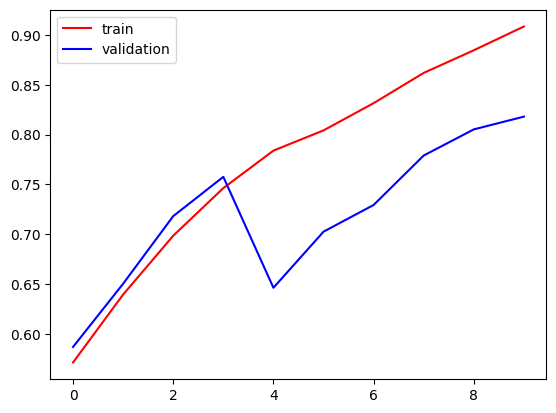

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

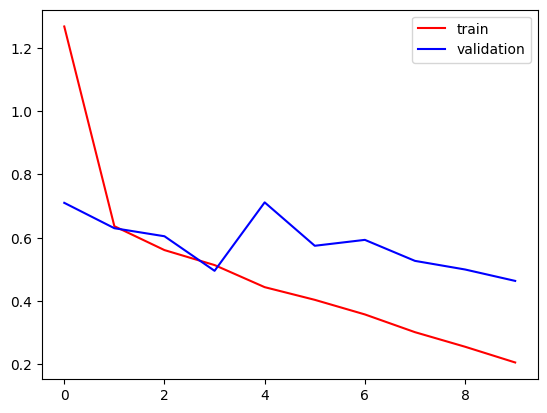

In [36]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [37]:
import cv2

In [38]:
test_img = cv2.imread('/content/oscar-sutton-yihlaRCCvd4-unsplash.jpg')

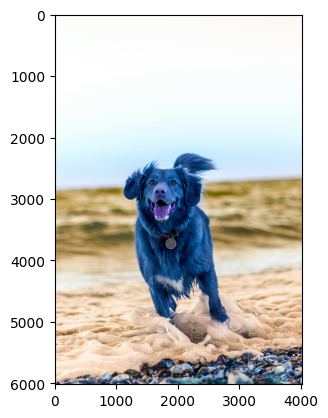

In [39]:
plt.imshow(test_img)

In [40]:
test_img.shape

(6016, 4016, 3)

In [41]:
test_img = cv2.resize(test_img,(256,256))

In [42]:
test_input = test_img.reshape((1,256,256,3))

In [43]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

In [44]:
test_img = cv2.imread('/content/manja-vitolic-gKXKBY-C-Dk-unsplash.jpg')

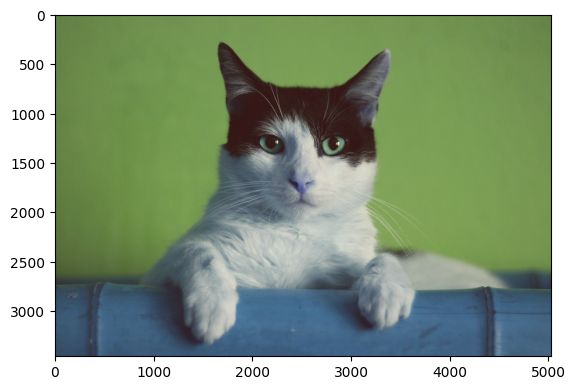

In [46]:
plt.imshow(test_img)

In [47]:
test_img.shape

(3458, 5026, 3)

In [48]:
test_img = cv2.resize(test_img,(256,256))

In [49]:
test_input = test_img.reshape((1,256,256,3))

In [50]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.]], dtype=float32)